# Tutorial 02 — FFT & Phổ Tần Số: Nhìn Rung Ở Góc Tần Số

> **Mục tiêu:** Hiểu FFT, vẽ phổ tần số, nhận diện tần số đặc trưng lỗi ổ lăn (BPFO, BPFI, BSF).
> Tất cả đều nằm trong dải **0–500 Hz**.

---

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
os.makedirs('../figures', exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from src.config import *
from src.signal_utils import load_one_sample_per_class

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
samples = load_one_sample_per_class(domain='0HP')
print("✅ Dữ liệu đã load.")

✅ Dữ liệu đã load.


## 1. FFT Là Gì? — Giải Thích Cho Kỹ Sư

**FFT (Fast Fourier Transform)** chuyển tín hiệu từ "biên độ theo thời gian" sang "biên độ theo tần số".

| Miền thời gian | Miền tần số |
|---|---|
| Thấy sóng dao động lên xuống | Thấy **tần số nào** rung mạnh nhất |
| Khó phân biệt Normal vs OR khi nhìn bằng mắt | FFT bộc lộ đỉnh tại BPFO=107Hz → xác nhận OR |

### Tần Số Đặc Trưng Ổ Lăn SKF 6205 @ 1797 RPM

| Tần số | Giá trị | Ý nghĩa |
|---|---|---|
| **1X** | ~30 Hz | Tần số quay cơ bản (1 vòng/s) |
| **BPFO** | 107 Hz | Bi đi qua vết lỗi rãnh NGOÀI |
| **BSF** | 141 Hz | Bi tự quay qua vết lỗi trên BI |
| **BPFI** | 162 Hz | Bi đi qua vết lỗi rãnh TRONG |

> ⚠️ **LƯU Ý QUAN TRỌNG:** Tất cả tần số lỗi đều ở dải **0–500 Hz**, KHÔNG phải 500–2000 Hz.

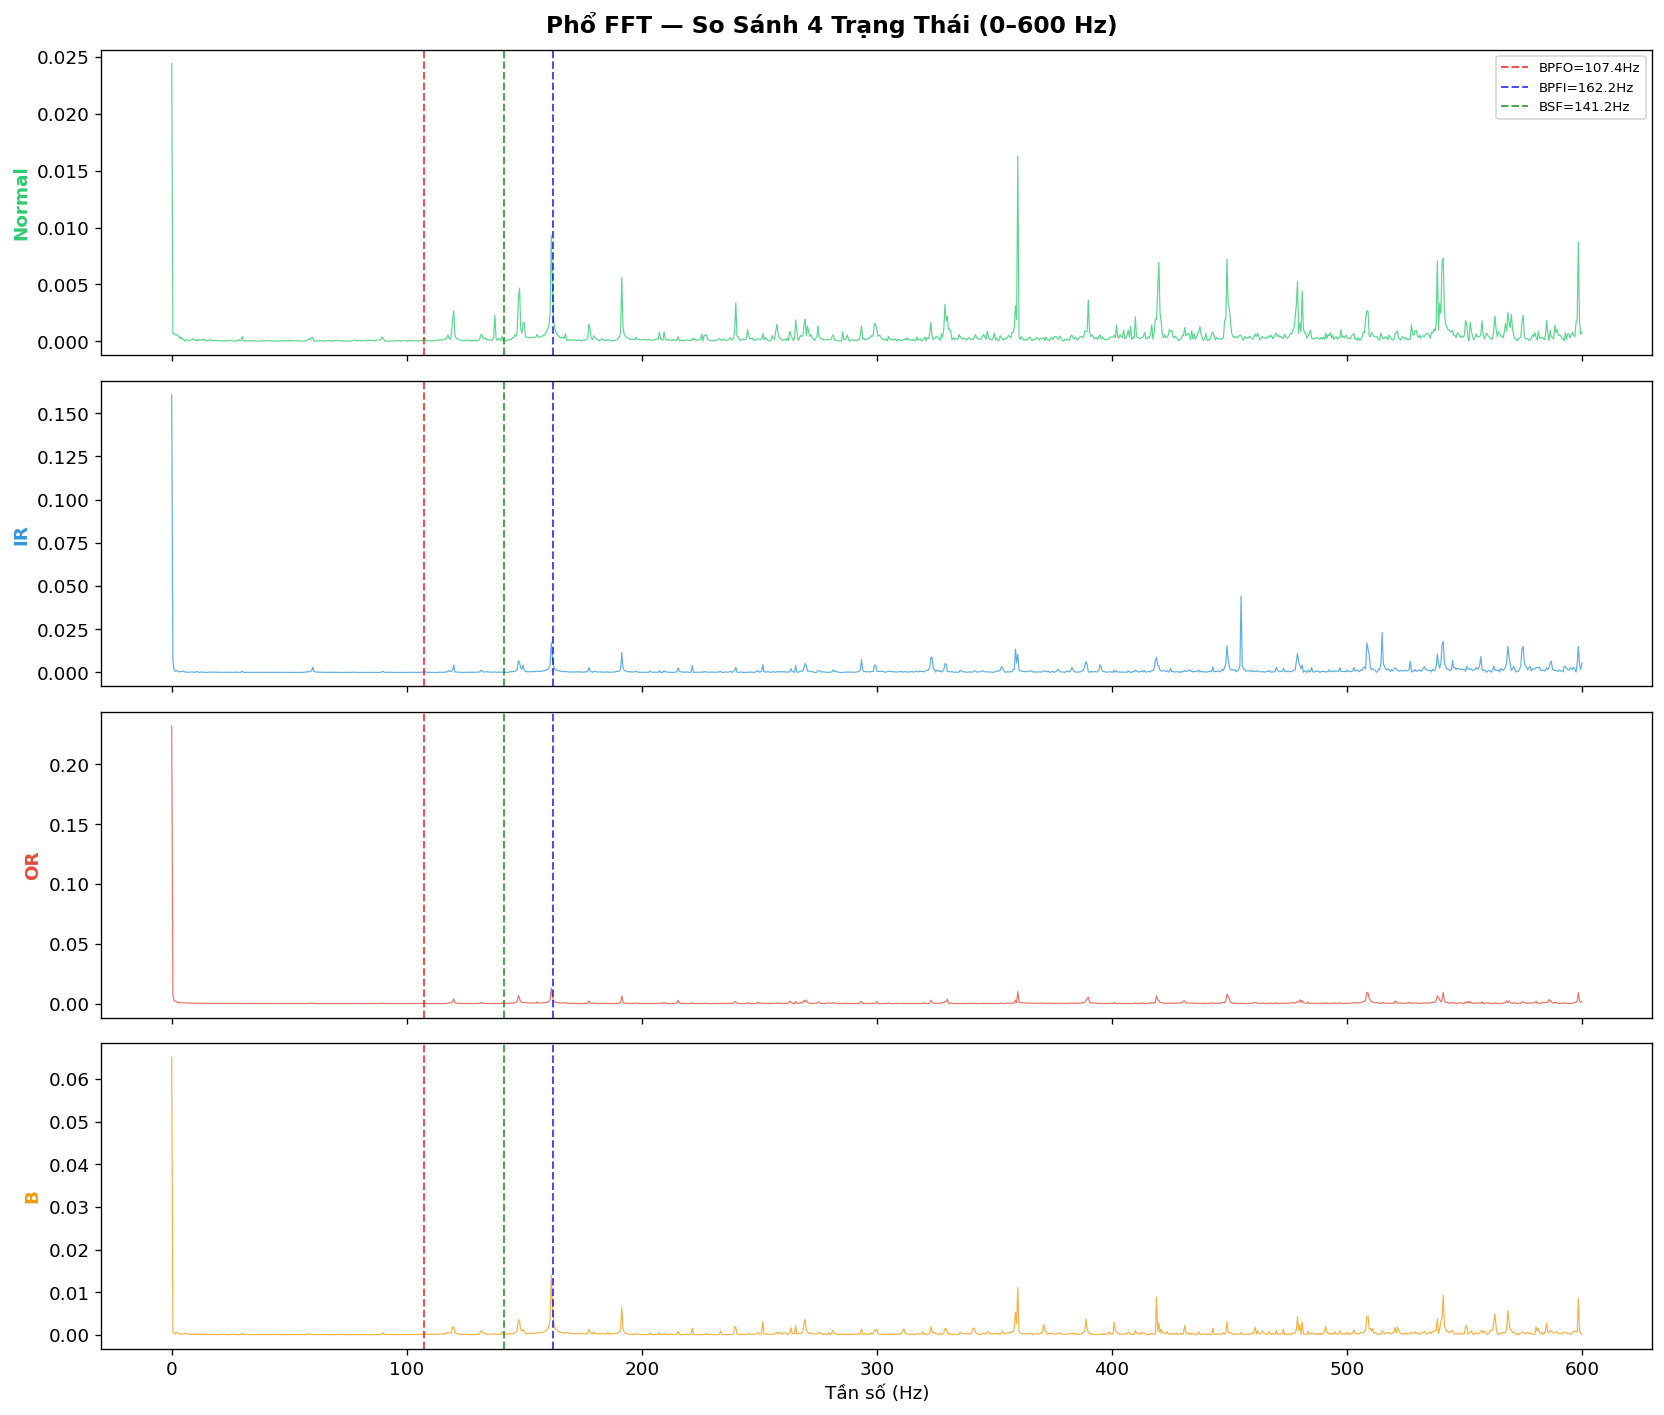

In [2]:
# Vẽ phổ FFT cho 4 trạng thái (0-600 Hz)
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Phổ FFT — So Sánh 4 Trạng Thái (0–600 Hz)', fontsize=14, fontweight='bold')

for ax, cls in zip(axes, CLASS_NAMES):
    if cls not in samples: continue
    sig = samples[cls]
    n = min(len(sig), FS * 2)  # Dùng 2 giây
    chunk = sig[:n]
    freqs = np.fft.fftfreq(n, 1/FS)[:n//2]
    fft_vals = np.abs(np.fft.fft(chunk)[:n//2]) * 2/n
    mask = freqs <= 600

    color = CLASS_COLORS[cls]
    ax.plot(freqs[mask], fft_vals[mask], lw=0.7, color=color, alpha=0.8)

    # Đánh dấu tần số lỗi
    for f, nm, c in [(BPFO,'BPFO','red'), (BPFI,'BPFI','blue'), (BSF,'BSF','green')]:
        ax.axvline(f, ls='--', lw=1.2, color=c, alpha=0.7, label=f'{nm}={f}Hz' if cls=='Normal' else '')
    ax.set_ylabel(f'{cls}', fontsize=11, color=color, fontweight='bold')
    if cls == 'Normal': ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xlabel('Tần số (Hz)')
plt.tight_layout()
plt.savefig('../figures/fft_4states.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔎 Đọc Phổ FFT Như Kỹ Sư

| Trạng thái | Đặc điểm phổ |
|---|---|
| **Normal** | Phổ phẳng, chỉ có đỉnh ở 1X (~30Hz), biên độ thấp |
| **OR** | Có thể thấy đỉnh nhỏ gần BPFO (107Hz) — nhưng thường bị chìm trong nhiễu |
| **IR** | Tương tự — đỉnh BPFI (162Hz) khó nhìn trên FFT thô |
| **B** | Khó nhìn nhất trên FFT thông thường |

> 💡 **Bài học:** FFT thông thường không đủ mạnh để chẩn đoán ổ lăn.
> Cần **Envelope Analysis** (Tutorial 02b) để "bóc tách" tần số lỗi ẩn sâu.

---
*Tutorial 02 hoàn tất. Tiếp theo: Tutorial 02b — Envelope Analysis.*